# Численные методы

Используемые библиотеки:
- numpy
- pandas
- matplotlib.pyplot
- seaborn
- math

In [1]:

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 6)

def table(df):
    return df.style.set_table_styles(
        [
            {"selector": "th", "props": [("background-color", "#4CAF50"), ("color", "white"), ("font-size", "12pt")]},
            {"selector": "td", "props": [("font-size", "11pt")]}
        ]
    ).set_properties(**{"text-align": "center"})

def scan(func, a, b, h):
    xs = np.arange(a, b + h, h, dtype=float)
    out = []
    x0 = xs[0]
    y0 = func(x0)
    for x1 in xs[1:]:
        y1 = func(x1)
        if y0 == 0 or y1 == 0 or y0 * y1 < 0:
            out.append((float(x0), float(x1)))
        x0, y0 = x1, y1
    return out

def show_intervals(intervals, digits=1):
    parts = []
    for a, b in intervals:
        ra = round(a, digits)
        rb = round(b, digits)
        if abs(ra) < 10**(-digits):
            ra = 0
        if abs(rb) < 10**(-digits):
            rb = 0
        parts.append(f"[{ra}; {rb}]")
    return ", ".join(parts)

def roots_on_grid(x, y):
    idx = np.where(y[:-1] * y[1:] <= 0)[0]
    roots = []
    for i in idx:
        x0, x1 = x[i], x[i + 1]
        y0, y1 = y[i], y[i + 1]
        if y0 == 0:
            r = x0
        elif y1 == 0:
            r = x1
        else:
            r = x0 - y0 * (x1 - x0) / (y1 - y0)
        if not roots or abs(r - roots[-1]) > 1e-3:
            roots.append(float(r))
    return roots

def bisection(func, a, b, eps):
    rows = []
    fa = func(a)
    fb = func(b)
    n = 0
    while (b - a) / 2 > eps:
        c = (a + b) / 2
        fc = func(c)
        rows.append([n, round(a, 6), round(b, 6), round(c, 6), round(fc, 6), round((b - a) / 2, 6)])
        if fa * fc <= 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc
        n += 1
    return (a + b) / 2, rows

def simple_iterations(phi, x0, eps, limit=100):
    rows = []
    x = x0
    for n in range(limit):
        xn = phi(x)
        d = abs(xn - x)
        rows.append([n, round(x, 6), round(xn, 6), round(d, 6)])
        if d < eps:
            return xn, rows
        x = xn
    return xn, rows


## 2.1
### Упражнение 1
а) $\lg x + 6 = x^2$

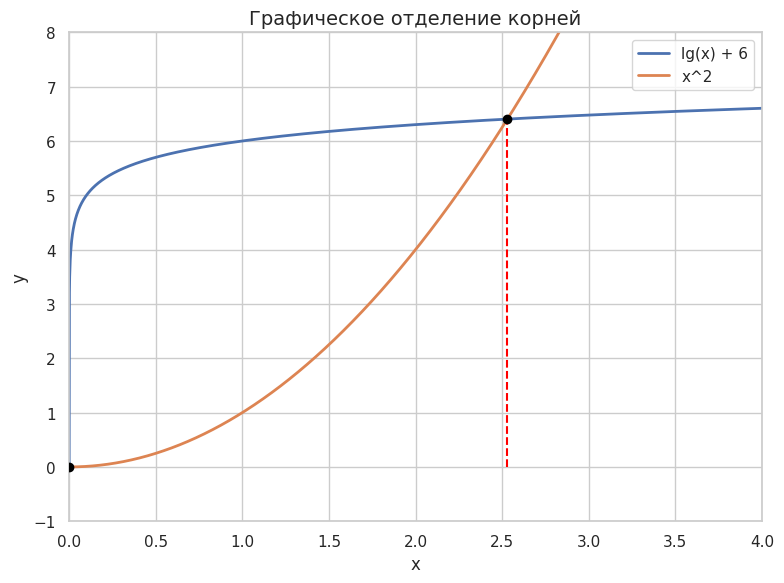

Ответ: [0; 0.1], [2.5; 2.6]


In [2]:

x = np.linspace(1e-6, 4, 2500)
y1 = np.log10(x) + 6
y2 = x**2
r = roots_on_grid(x, y1 - y2)

plt.figure(figsize=(8, 6))
plt.plot(x, y1, label="lg(x) + 6", linewidth=2)
plt.plot(x, y2, label="x^2", linewidth=2)

for xi in r:
    yi = np.interp(xi, x, y1)
    plt.scatter(xi, yi, color="black", zorder=5)
    plt.vlines(xi, 0, yi, colors="red", linestyles="dashed", linewidth=1.5)

plt.xlim(0, 4)
plt.ylim(-1, 8)
plt.title("Графическое отделение корней", fontsize=14)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

f = lambda t: math.log10(t) + 6 - t**2
intervals = scan(f, 1e-6, 4, 0.1)
print("Ответ:", show_intervals(intervals))


б) $x\sin x - 1 = 0$

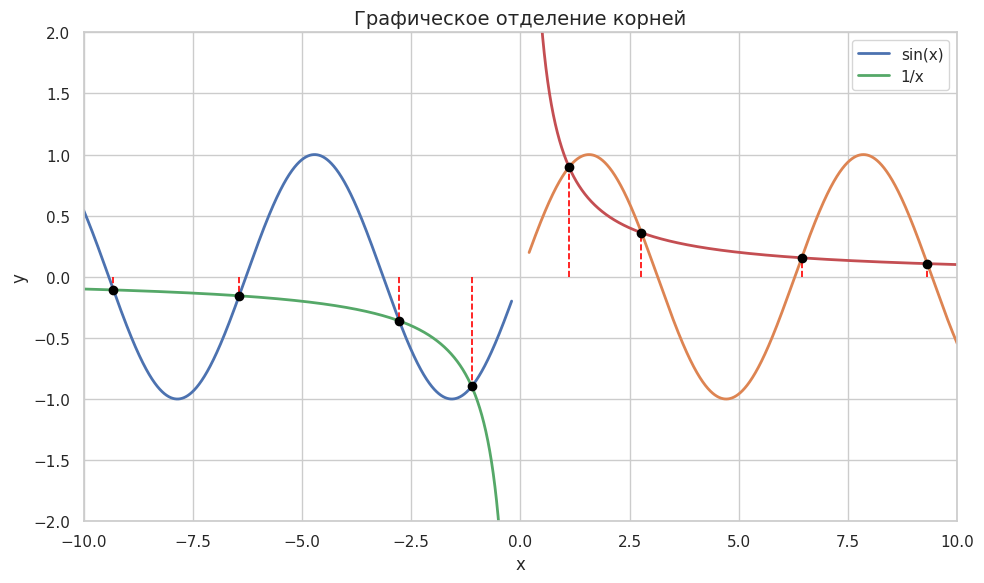

Ответ: [-9.4; -9.3], [-6.5; -6.4], [-2.8; -2.7], [-1.2; -1.1], [1.1; 1.2], [2.7; 2.8], [6.4; 6.5], [9.3; 9.4]


In [3]:

x1 = np.linspace(-10, -0.2, 3000)
x2 = np.linspace(0.2, 10, 3000)
d1 = np.sin(x1) - 1 / x1
d2 = np.sin(x2) - 1 / x2
r = roots_on_grid(x1, d1) + roots_on_grid(x2, d2)

plt.figure(figsize=(10, 6))
plt.plot(x1, np.sin(x1), linewidth=2, label="sin(x)")
plt.plot(x2, np.sin(x2), linewidth=2)
plt.plot(x1, 1 / x1, linewidth=2, label="1/x")
plt.plot(x2, 1 / x2, linewidth=2)

for xi in r:
    yi = math.sin(xi)
    plt.scatter(xi, yi, color="black", zorder=5)
    plt.vlines(xi, 0, yi, colors="red", linestyles="dashed", linewidth=1.2)

plt.xlim(-10, 10)
plt.ylim(-2, 2)
plt.title("Графическое отделение корней", fontsize=14)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

g = lambda t: t * math.sin(t) - 1
intervals = scan(g, -10, 10, 0.1)
print("Ответ:", show_intervals(intervals))


## 2.2
### Упражнение
$x\sin x - 1 = 0$, метод половинного деления, $\varepsilon = 10^{-4}$

In [4]:

f = lambda x: x * math.sin(x) - 1
x, rows = bisection(f, 1.1, 1.2, 1e-4)
df = pd.DataFrame(rows, columns=["n", "a", "b", "c", "f(c)", "Δ"])
display(table(df))
print(f"Ответ: x ≈ {x:.6f}")


,n,a,b,c,f(c),Δ
0,0,1.100000,1.200000,1.150000,0.049679,0.050000
1,1,1.100000,1.150000,1.125000,0.015051,0.025000
2,2,1.100000,1.125000,1.112500,-0.002302,0.012500
3,3,1.112500,1.125000,1.118750,0.006377,0.006250
4,4,1.112500,1.118750,1.115625,0.002038,0.003125
5,5,1.112500,1.115625,1.114063,-0.000131,0.001563
6,6,1.114063,1.115625,1.114844,0.000954,0.000781
7,7,1.114063,1.114844,1.114453,0.000411,0.000391
8,8,1.114063,1.114453,1.114258,0.000140,0.000195


Ответ: x ≈ 1.114160


## 2.3
### Упражнение 1
Графическая иллюстрация сходящегося итерационного процесса

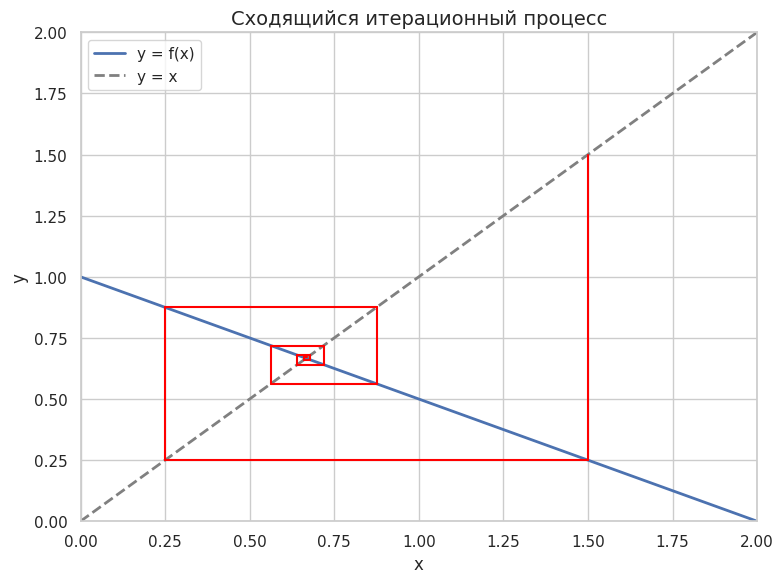

In [5]:

phi = lambda x: 1 - 0.5 * x
a, b = 0, 2
x = np.linspace(a, b, 500)
y = phi(x)

points = [1.5]
for _ in range(8):
    points.append(phi(points[-1]))

plt.figure(figsize=(8, 6))
plt.plot(x, y, linewidth=2, label="y = f(x)")
plt.plot(x, x, linewidth=2, linestyle="--", color="gray", label="y = x")

for i in range(len(points) - 1):
    plt.plot([points[i], points[i]], [points[i], points[i + 1]], color="red", linewidth=1.5)
    plt.plot([points[i], points[i + 1]], [points[i + 1], points[i + 1]], color="red", linewidth=1.5)

plt.xlim(a, b)
plt.ylim(a, b)
plt.title("Сходящийся итерационный процесс", fontsize=14)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()


### Упражнение 2
$x\sin x - 1 = 0$, метод простой итерации, $\varepsilon = 10^{-5}$

In [6]:

F = lambda x: x * math.sin(x) - 1
phi = lambda x: x - 0.5 * F(x)

x, rows = simple_iterations(phi, 1.0, 1e-5)
df = pd.DataFrame(rows, columns=["n", "x_n", "x_(n+1)", "|x_(n+1)-x_n|"])
display(table(df))
print(f"Ответ: x ≈ {x:.6f}")


,n,x_n,x_(n+1),|x_(n+1)-x_n|
0,0,1.000000,1.079265,0.079265
1,1,1.079265,1.103519,0.024254
2,2,1.103519,1.110909,0.007390
3,3,1.110909,1.113165,0.002256
4,4,1.113165,1.113854,0.000689
5,5,1.113854,1.114064,0.000211
6,6,1.114064,1.114129,0.000064
7,7,1.114129,1.114148,0.000020
8,8,1.114148,1.114154,0.000006


Ответ: x ≈ 1.114154


## 2.5
### Упражнение 1
Графическая иллюстрация методов хорд и касательных

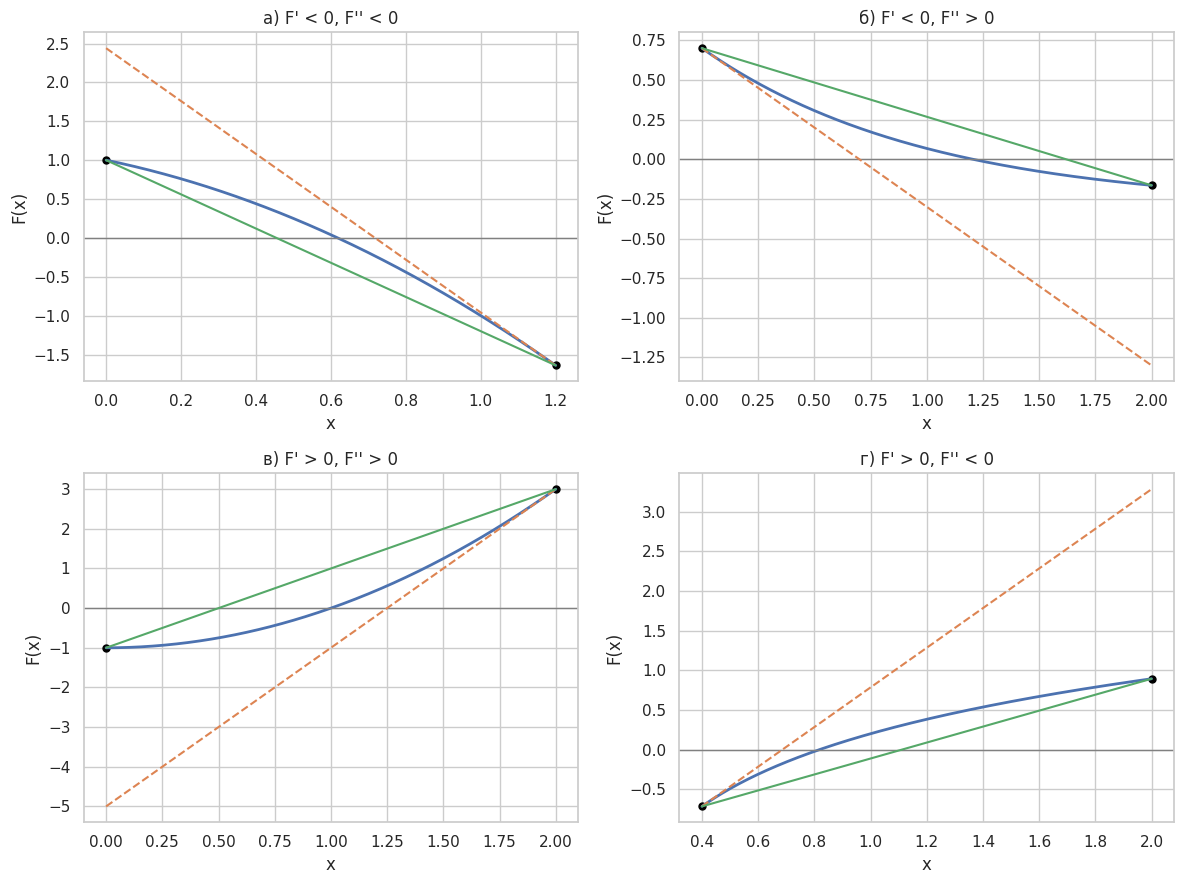

In [7]:

def plot_case(ax, f, df, a, b, c, title):
    x = np.linspace(a, b, 500)
    y = f(x)
    ax.plot(x, y, linewidth=2)
    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)
    y0 = f(c)
    y1 = f(a + b - c)
    xx = np.linspace(a, b, 200)
    ax.plot(xx, y0 + df(c) * (xx - c), linestyle="--", linewidth=1.5)
    ax.plot([c, a + b - c], [y0, y1], linewidth=1.5)
    ax.scatter([c, a + b - c], [y0, y1], color="black", s=25)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("F(x)")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

plot_case(axes[0, 0], lambda x: 1 - x - x**2, lambda x: -1 - 2*x, 0, 1.2, 1.2, "а) F' < 0, F'' < 0")
plot_case(axes[0, 1], lambda x: np.exp(-x) - 0.3, lambda x: -np.exp(-x), 0, 2, 0, "б) F' < 0, F'' > 0")
plot_case(axes[1, 0], lambda x: x**2 - 1, lambda x: 2*x, 0, 2, 2, "в) F' > 0, F'' > 0")
plot_case(axes[1, 1], lambda x: np.log(x) + 0.2, lambda x: 1/x, 0.4, 2, 0.4, "г) F' > 0, F'' < 0")

plt.tight_layout()
plt.show()


### Упражнение 2
$x^3 + 3x^2 - 24x + 1 = 0$, комбинированный метод, $[0; 1]$, $\varepsilon = 10^{-6}$

In [8]:

F = lambda x: x**3 + 3*x**2 - 24*x + 1
dF = lambda x: 3*x**2 + 6*x - 24
ddF = lambda x: 6*x + 6

a, b = 0, 1
if F(a) * ddF(a) > 0:
    c = a
    xt = a
    xh = b
else:
    c = b
    xt = b
    xh = a

rows = []
for n in range(20):
    xt1 = xt - F(xt) / dF(xt)
    xh1 = (c * F(xh) - xh * F(c)) / (F(xh) - F(c))
    mid = (xt1 + xh1) / 2
    d = abs(xt1 - xh1) / 2
    rows.append([n, round(xt1, 6), round(xh1, 6), round(mid, 6), round(d, 6)])
    if d < 1e-6:
        break
    xt, xh = xt1, xh1

df = pd.DataFrame(rows, columns=["n", "касат.", "хорды", "середина", "Δ"])
display(table(df))
print(f"Ответ: x ≈ {mid:.6f}")


,n,касат.,хорды,середина,Δ
0,0,0.041667,0.050000,0.045833,0.004167
1,1,0.041889,0.041933,0.041911,0.000022
2,2,0.041889,0.041889,0.041889,0.000000


Ответ: x ≈ 0.041889


## 2.6
### Упражнение 1
$\lg x - \cos x = 0$, метод половинного деления

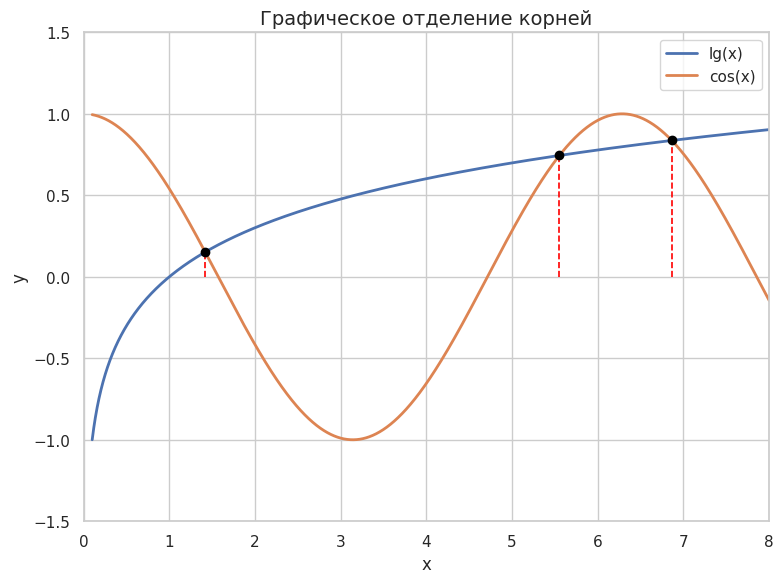

Ответ: [1; 2], [5; 6], [6; 7]


,n,a,b,c,f(c),Δ
0,0,1.000000,2.000000,1.500000,0.105354,0.500000
1,1,1.000000,1.500000,1.250000,-0.218412,0.250000
2,2,1.250000,1.500000,1.375000,-0.056245,0.125000
3,3,1.375000,1.500000,1.437500,0.024706,0.062500
4,4,1.375000,1.437500,1.406250,-0.015742,0.031250
5,5,1.406250,1.437500,1.421875,0.004490,0.015625
6,6,1.406250,1.421875,1.414062,-0.005624,0.007812
7,7,1.414062,1.421875,1.417969,-0.000567,0.003906
8,8,1.417969,1.421875,1.419922,0.001962,0.001953
9,9,1.417969,1.419922,1.418945,0.000698,0.000977


Корень: x ≈ 1.4184


In [9]:

x = np.linspace(0.1, 8, 3000)
y1 = np.log10(x)
y2 = np.cos(x)
r = roots_on_grid(x, y1 - y2)

plt.figure(figsize=(8, 6))
plt.plot(x, y1, linewidth=2, label="lg(x)")
plt.plot(x, y2, linewidth=2, label="cos(x)")

for xi in r:
    yi = np.interp(xi, x, y1)
    plt.scatter(xi, yi, color="black", zorder=5)
    plt.vlines(xi, 0, yi, colors="red", linestyles="dashed", linewidth=1.2)

plt.xlim(0, 8)
plt.ylim(-1.5, 1.5)
plt.title("Графическое отделение корней", fontsize=14)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

f = lambda x: math.log10(x) - math.cos(x)
print("Ответ:", "[1; 2], [5; 6], [6; 7]")

x, rows = bisection(f, 1, 2, 1e-4)
df = pd.DataFrame(rows, columns=["n", "a", "b", "c", "f(c)", "Δ"])
display(table(df))
print(f"Корень: x ≈ {x:.4f}")


### Упражнение 2
$x^2 - 3.2x = 1$, метод простой итерации, $\varepsilon = 10^{-4}$

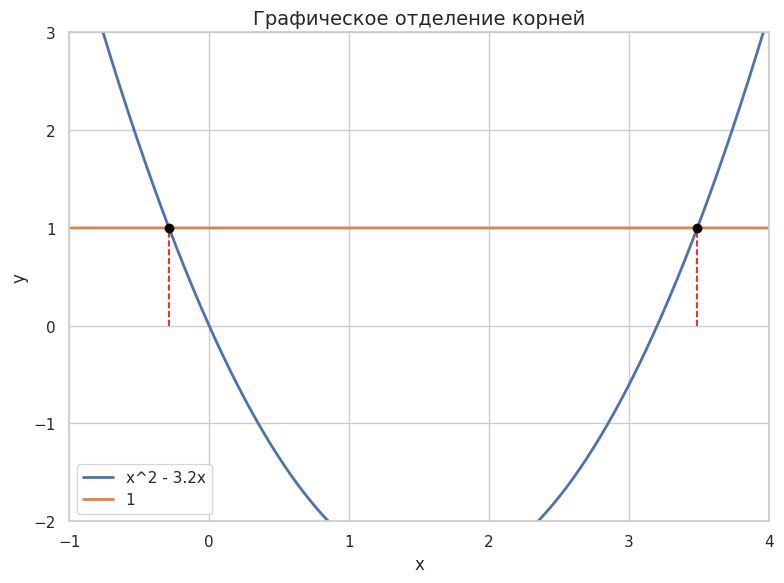

,n,x_n,x_(n+1),|x_(n+1)-x_n|
0,0,3.500000,3.492850,0.007150
1,1,3.492850,3.489573,0.003277
2,2,3.489573,3.488070,0.001503
3,3,3.488070,3.487381,0.000689
4,4,3.487381,3.487064,0.000316
5,5,3.487064,3.486919,0.000145
6,6,3.486919,3.486853,0.000067
7,7,3.486853,3.486822,0.000031
8,8,3.486822,3.486808,0.000014
9,9,3.486808,3.486802,0.000006


Ответ: [-1; 0], [3; 4]
Один корень: x ≈ 3.4868


In [10]:

x = np.linspace(-1, 4, 1500)
y1 = x**2 - 3.2 * x
y2 = np.ones_like(x)
r = roots_on_grid(x, y1 - y2)

plt.figure(figsize=(8, 6))
plt.plot(x, y1, linewidth=2, label="x^2 - 3.2x")
plt.plot(x, y2, linewidth=2, label="1")

for xi in r:
    yi = np.interp(xi, x, y1)
    plt.scatter(xi, yi, color="black", zorder=5)
    plt.vlines(xi, 0, yi, colors="red", linestyles="dashed", linewidth=1.2)

plt.xlim(-1, 4)
plt.ylim(-2, 3)
plt.title("Графическое отделение корней", fontsize=14)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

phi = lambda x: math.sqrt(3.2 * x + 1)
x, rows = simple_iterations(phi, 3.5, 1e-5)
df = pd.DataFrame(rows, columns=["n", "x_n", "x_(n+1)", "|x_(n+1)-x_n|"])
display(table(df))
print("Ответ: [-1; 0], [3; 4]")
print(f"Один корень: x ≈ {x:.4f}")


### Упражнение 3
$4x - 3\ln x = 4$, метод простой итерации, $\varepsilon = 10^{-4}$

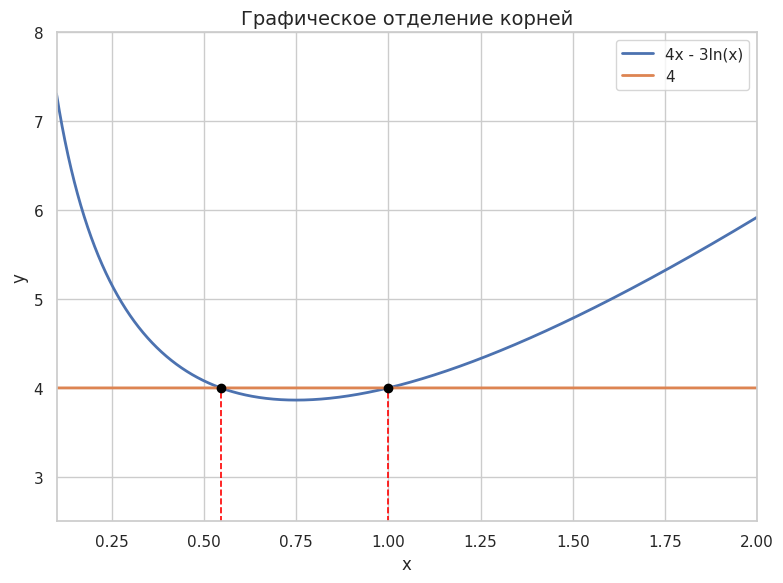

,n,x_n,x_(n+1),|x_(n+1)-x_n|
0,0,1.010000,1.007463,0.002537
1,1,1.007463,1.005576,0.001886
2,2,1.005576,1.004171,0.001406
3,3,1.004171,1.003121,0.001049
4,4,1.003121,1.002337,0.000784
5,5,1.002337,1.001751,0.000586
6,6,1.001751,1.001312,0.000439
7,7,1.001312,1.000983,0.000329
8,8,1.000983,1.000737,0.000246
9,9,1.000737,1.000553,0.000185


Ответ: [0.5; 0.6], [0.9; 1.1]
Наибольший положительный корень: x ≈ 1.0000


In [11]:

x = np.linspace(0.1, 2, 2000)
y1 = 4 * x - 3 * np.log(x)
y2 = np.full_like(x, 4.0)
r = roots_on_grid(x, y1 - y2)

plt.figure(figsize=(8, 6))
plt.plot(x, y1, linewidth=2, label="4x - 3ln(x)")
plt.plot(x, y2, linewidth=2, label="4")

for xi in r:
    yi = np.interp(xi, x, y1)
    plt.scatter(xi, yi, color="black", zorder=5)
    plt.vlines(xi, 0, yi, colors="red", linestyles="dashed", linewidth=1.2)

plt.xlim(0, 2)
plt.ylim(0, 8)
plt.title("Графическое отделение корней", fontsize=14)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

phi = lambda x: 1 + 0.75 * math.log(x)
x, rows = simple_iterations(phi, 1.01, 1e-5)
df = pd.DataFrame(rows, columns=["n", "x_n", "x_(n+1)", "|x_(n+1)-x_n|"])
display(table(df))
print("Ответ: [0.5; 0.6], [0.9; 1.1]")
print(f"Наибольший положительный корень: x ≈ {x:.4f}")
